<a href="https://colab.research.google.com/github/ChunHajin/wellbore-tvt-prediction/blob/main/ROGII.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

## 2주차 EDA

In [2]:
# [1] 구글 드라이브 마운트
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [3]:
# [2] 라이브러리 import
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import os

plt.rcParams['figure.figsize'] = (16, 5)
plt.rcParams['font.size'] = 11

# 한글 폰트 설치 및 등록
import subprocess
subprocess.run(['apt-get', 'install', '-y', 'fonts-nanum'], capture_output=True)

import matplotlib.font_manager as fm
fm.fontManager.addfont('/usr/share/fonts/truetype/nanum/NanumGothic.ttf')

import matplotlib.pyplot as plt
plt.rcParams['font.family'] = 'NanumGothic'
plt.rcParams['axes.unicode_minus'] = False

In [4]:
# [3] 경로 설정 & 데이터 로드
BASE_PATH = '/content/drive/MyDrive/ROGII'

WELL_NAME = '000d7d20'   # 분석할 웰 이름

hw = pd.read_csv(f'{BASE_PATH}/train/{WELL_NAME}__horizontal_well.csv')
tw = pd.read_csv(f'{BASE_PATH}/train/{WELL_NAME}__typewell.csv')

print(f'수평정 shape: {hw.shape}')
print(f'Typewell shape: {tw.shape}')

수평정 shape: (5278, 13)
Typewell shape: (1296, 3)


In [5]:
# [4] 기본 정보 확인
print('===== 수평정 컬럼 =====')
print(hw.dtypes)
print()
print('===== 수평정 기초 통계 =====')
print(hw.describe())

===== 수평정 컬럼 =====
MD           float64
X            float64
Y            float64
Z            float64
ANCC         float64
ASTNU        float64
ASTNL        float64
EGFDU        float64
EGFDL        float64
BUDA         float64
TVT          float64
GR           float64
TVT_input    float64
dtype: object

===== 수평정 기초 통계 =====
                 MD             X             Y            Z         ANCC  \
count   5278.000000  5.278000e+03  5.278000e+03  5278.000000  5278.000000   
mean   14105.500000  2.983514e+06  1.071418e+06 -9673.194324 -9330.621821   
std     1523.771691  2.997379e+01  1.503381e+03    80.961903    35.272977   
min    11467.000000  2.983468e+06  1.069022e+06 -9755.610000 -9395.810000   
25%    12786.250000  2.983487e+06  1.070090e+06 -9721.762500 -9362.307500   
50%    14105.500000  2.983514e+06  1.071407e+06 -9689.230000 -9335.975000   
75%    15424.750000  2.983535e+06  1.072723e+06 -9650.035000 -9296.665000   
max    16744.000000  2.983578e+06  1.074041e+06 -9258.5

In [6]:
# [5] NaN 현황 확인
print('===== 수평정 NaN 개수 =====')
nan_counts = hw.isnull().sum()
nan_pct = (nan_counts / len(hw) * 100).round(1)
nan_df = pd.DataFrame({'NaN 개수': nan_counts, 'NaN 비율(%)': nan_pct})
print(nan_df[nan_df['NaN 개수'] > 0])

print()
print('===== Typewell NaN 개수 =====')
print(tw.isnull().sum())

===== 수평정 NaN 개수 =====
           NaN 개수  NaN 비율(%)
GR           2258       42.8
TVT_input    3836       72.7

===== Typewell NaN 개수 =====
TVT          0
GR           0
Geology    299
dtype: int64


In [7]:
# [6] PS(Prediction Start) 지점 찾기
# TVT_input이 NaN이 아닌 마지막 행 = PS 직전
ps_idx = hw['TVT_input'].last_valid_index()
ps_md  = hw.loc[ps_idx, 'MD']

print(f'PS 지점 index : {ps_idx}')
print(f'PS 지점 MD    : {ps_md:.1f} ft')
print(f'PS 이전 구간  : {ps_idx + 1} 행')
print(f'PS 이후 구간  : {len(hw) - ps_idx - 1} 행  ← 예측 대상')

PS 지점 index : 1441
PS 지점 MD    : 12908.0 ft
PS 이전 구간  : 1442 행
PS 이후 구간  : 3836 행  ← 예측 대상


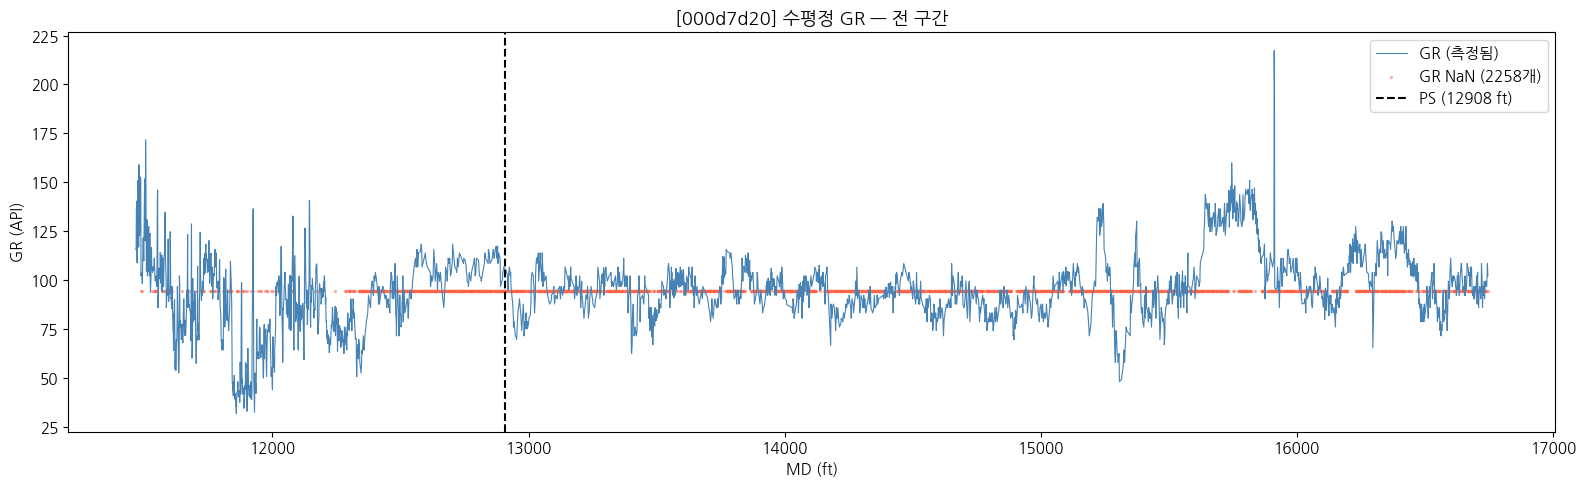

In [8]:
# [7] 수평정 GR 시각화
fig, ax = plt.subplots()

# GR이 있는 구간 / 없는 구간 분리
gr_valid = hw[hw['GR'].notna()]
gr_nan   = hw[hw['GR'].isna()]

ax.plot(gr_valid['MD'], gr_valid['GR'], color='steelblue', linewidth=0.8, label='GR (측정됨)')
ax.scatter(gr_nan['MD'], [hw['GR'].mean()] * len(gr_nan),
           color='tomato', s=2, alpha=0.4, label=f'GR NaN ({len(gr_nan)}개)')
ax.axvline(ps_md, color='black', linestyle='--', linewidth=1.5, label=f'PS ({ps_md:.0f} ft)')

ax.set_xlabel('MD (ft)')
ax.set_ylabel('GR (API)')
ax.set_title(f'[{WELL_NAME}] 수평정 GR — 전 구간')
ax.legend()
plt.tight_layout()
plt.show()

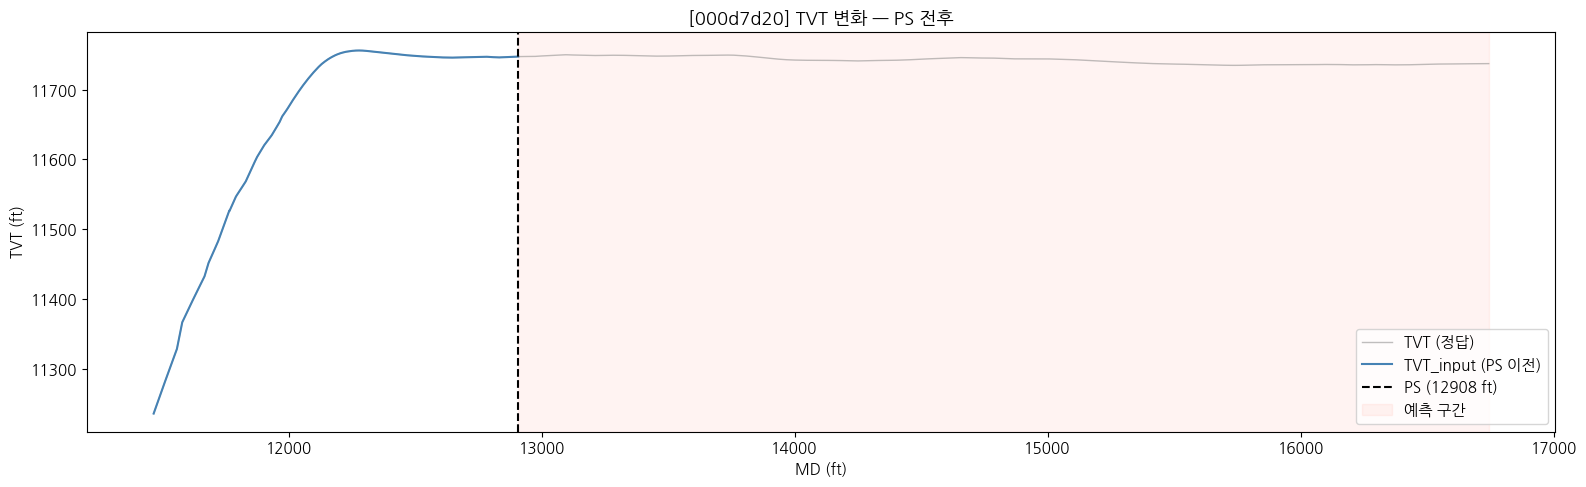

In [9]:
# [8] TVT 및 TVT_input 시각화
fig, ax = plt.subplots()

ax.plot(hw['MD'], hw['TVT'],       color='gray',      linewidth=1,   alpha=0.5, label='TVT (정답)')
ax.plot(hw['MD'], hw['TVT_input'], color='steelblue', linewidth=1.5, label='TVT_input (PS 이전)')
ax.axvline(ps_md, color='black', linestyle='--', linewidth=1.5, label=f'PS ({ps_md:.0f} ft)')

# 예측 구간 음영
ax.axvspan(ps_md, hw['MD'].max(), alpha=0.07, color='tomato', label='예측 구간')

ax.set_xlabel('MD (ft)')
ax.set_ylabel('TVT (ft)')
ax.set_title(f'[{WELL_NAME}] TVT 변화 — PS 전후')
ax.legend()
plt.tight_layout()
plt.show()

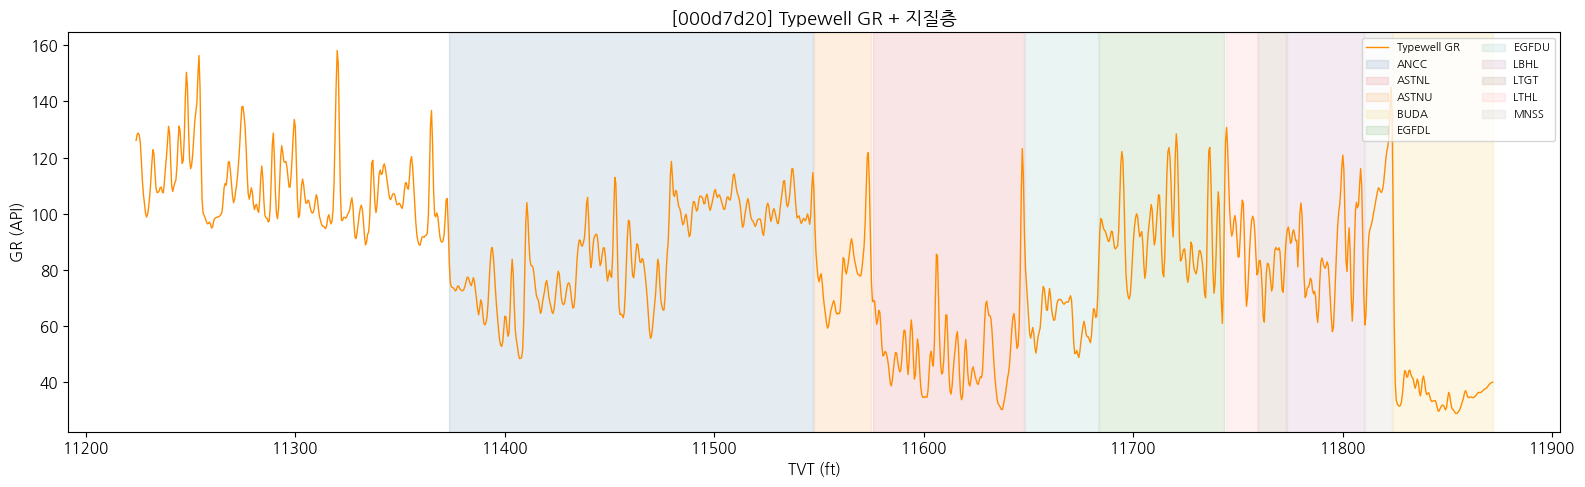

In [10]:
# [9] Typewell GR 및 지질층 시각화
fig, ax = plt.subplots()

ax.plot(tw['TVT'], tw['GR'], color='darkorange', linewidth=1, label='Typewell GR')

# 지질층 경계 표시
geology_colors = {
    'ANCC': '#4e79a7', 'ASTNU': '#f28e2b', 'ASTNL': '#e15759',
    'EGFDU': '#76b7b2', 'EGFDL': '#59a14f', 'BUDA': '#edc948',
    'LBHL': '#b07aa1', 'LTHL': '#ff9da7', 'LTGT': '#9c755f', 'MNSS': '#bab0ac'
}
tw_geo = tw.dropna(subset=['Geology'])
for geo, group in tw_geo.groupby('Geology'):
    color = geology_colors.get(geo, 'gray')
    ax.axvspan(group['TVT'].min(), group['TVT'].max(), alpha=0.15, color=color, label=geo)

ax.set_xlabel('TVT (ft)')
ax.set_ylabel('GR (API)')
ax.set_title(f'[{WELL_NAME}] Typewell GR + 지질층')
ax.legend(loc='upper right', fontsize=8, ncol=2)
plt.tight_layout()
plt.show()

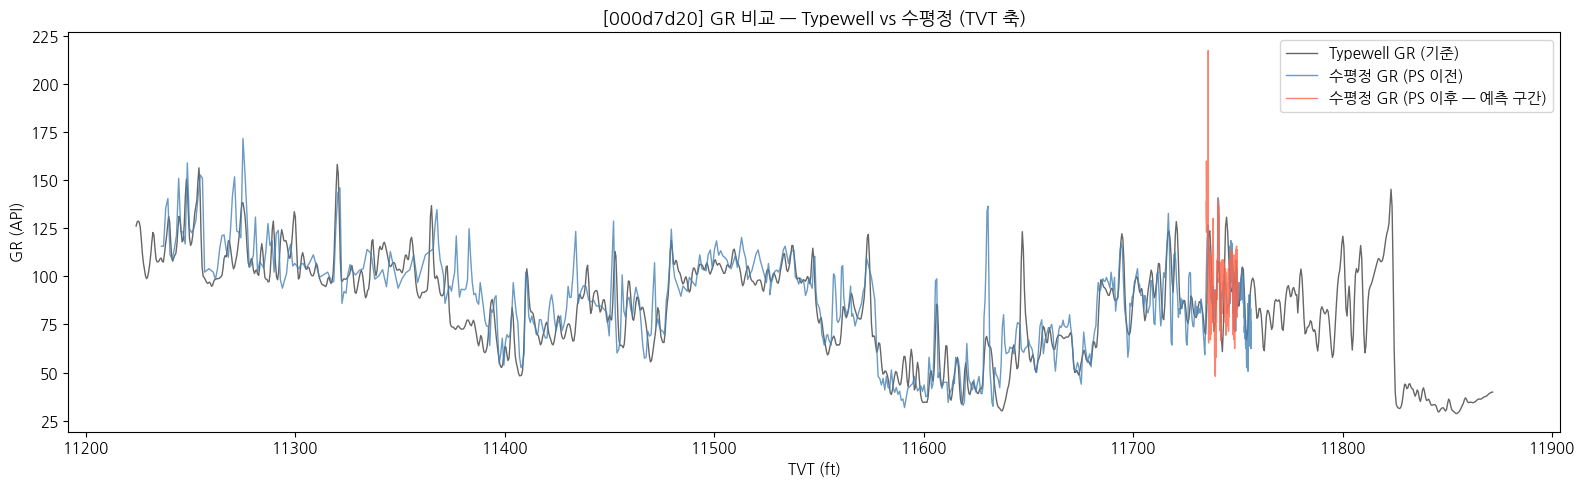

In [11]:
# [10] 수평정 GR vs Typewell GR 비교 (TVT 축 기준)
# 수평정 GR을 TVT 축에 투영해서 Typewell GR과 비교
fig, ax = plt.subplots()

# Typewell
ax.plot(tw['TVT'], tw['GR'],
        color='black', linewidth=1, alpha=0.6, label='Typewell GR (기준)')

# PS 이전 수평정 GR
hw_before = hw[(hw['MD'] <= ps_md) & hw['GR'].notna()]
ax.plot(hw_before['TVT'], hw_before['GR'],
        color='steelblue', linewidth=1, alpha=0.8, label='수평정 GR (PS 이전)')

# PS 이후 수평정 GR
hw_after = hw[(hw['MD'] > ps_md) & hw['GR'].notna()]
ax.plot(hw_after['TVT'], hw_after['GR'],
        color='tomato', linewidth=1, alpha=0.8, label='수평정 GR (PS 이후 — 예측 구간)')

ax.set_xlabel('TVT (ft)')
ax.set_ylabel('GR (API)')
ax.set_title(f'[{WELL_NAME}] GR 비교 — Typewell vs 수평정 (TVT 축)')
ax.legend()
plt.tight_layout()
plt.show()

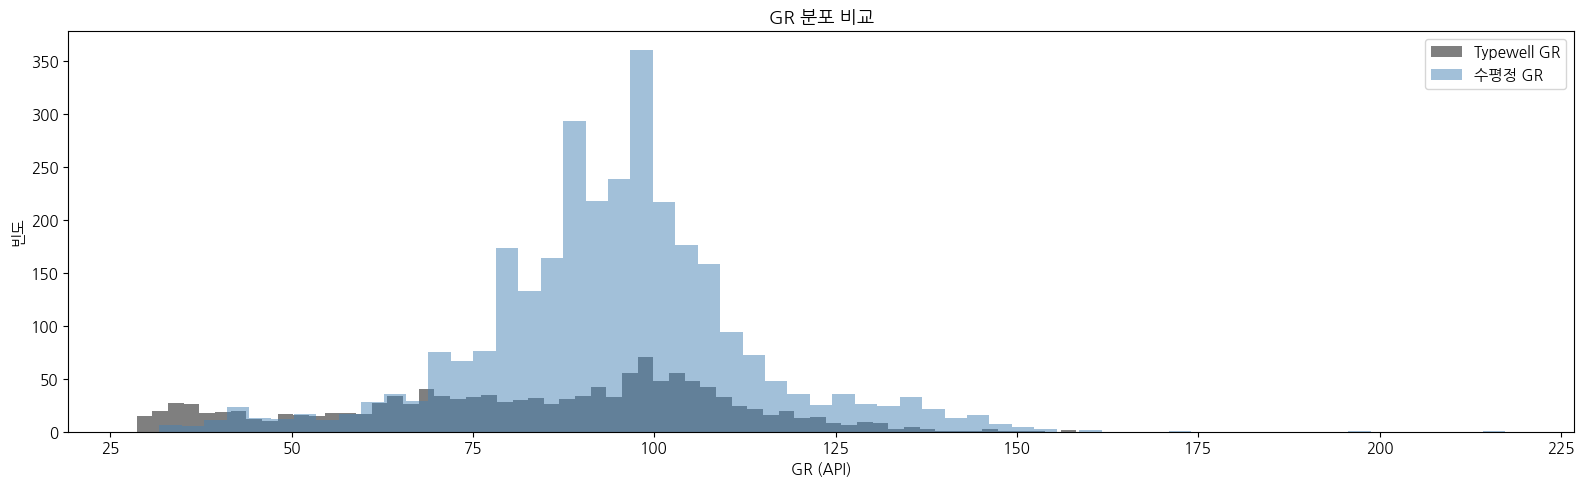

In [12]:
# [11] GR 분포 비교 (히스토그램)
fig, ax = plt.subplots()

ax.hist(tw['GR'],      bins=60, alpha=0.5, color='black',     label='Typewell GR')
ax.hist(hw['GR'].dropna(), bins=60, alpha=0.5, color='steelblue', label='수평정 GR')

ax.set_xlabel('GR (API)')
ax.set_ylabel('빈도')
ax.set_title('GR 분포 비교')
ax.legend()
plt.tight_layout()
plt.show()


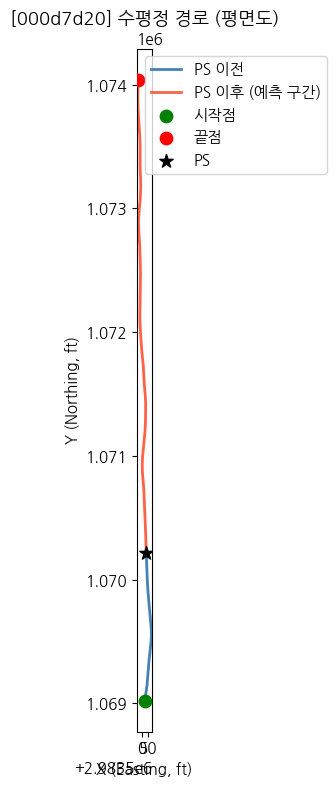

EDA 수행 완료


In [13]:
# [12] 웰 경로 2D 시각화 (X-Y 평면)
fig, ax = plt.subplots(figsize=(8, 8))

before = hw[hw['MD'] <= ps_md]
after  = hw[hw['MD'] >  ps_md]

ax.plot(before['X'], before['Y'], color='steelblue', linewidth=2, label='PS 이전')
ax.plot(after['X'],  after['Y'],  color='tomato',    linewidth=2, label='PS 이후 (예측 구간)')
ax.scatter(hw['X'].iloc[0],  hw['Y'].iloc[0],  color='green', s=80, zorder=5, label='시작점')
ax.scatter(hw['X'].iloc[-1], hw['Y'].iloc[-1], color='red',   s=80, zorder=5, label='끝점')
ax.scatter(before['X'].iloc[-1], before['Y'].iloc[-1],
           color='black', s=100, marker='*', zorder=5, label=f'PS')

ax.set_xlabel('X (Easting, ft)')
ax.set_ylabel('Y (Northing, ft)')
ax.set_title(f'[{WELL_NAME}] 수평정 경로 (평면도)')
ax.legend()
ax.set_aspect('equal')
plt.tight_layout()
plt.show()

print('EDA 수행 완료')

## 3주차 전처리

보간 전 GR NaN: 0
보간 후 GR NaN: 0
이상치 기준값 (99th percentile): 141.6 API
이상치 개수: 53개
처리 후 GR 최대값: 141.6 API


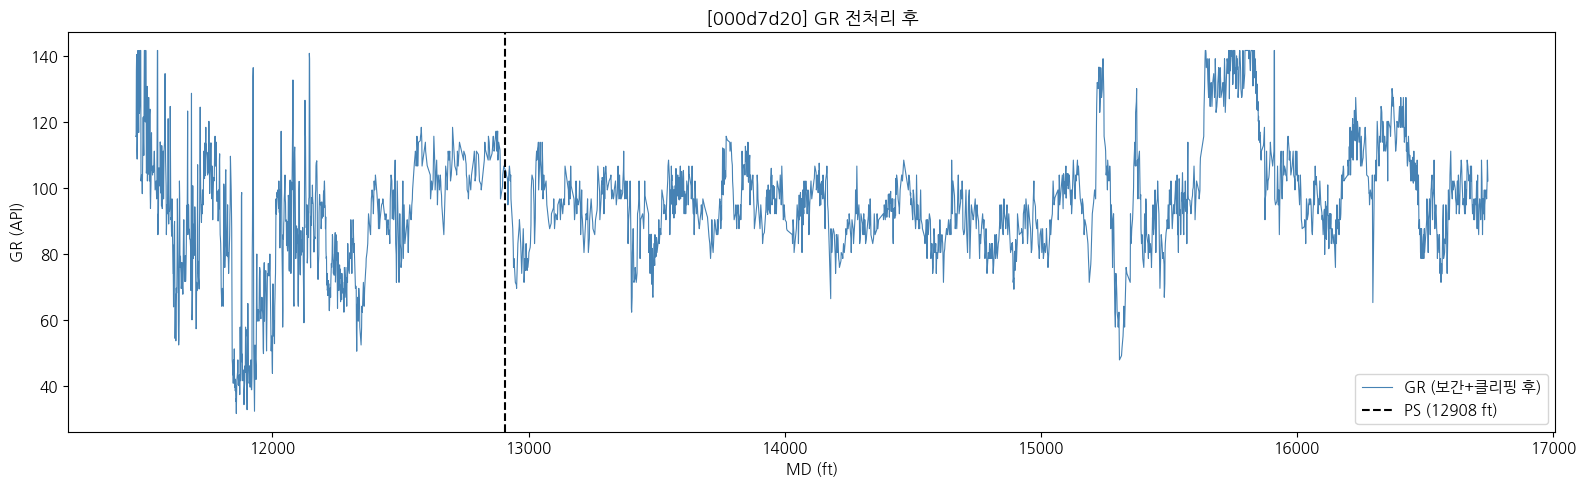

In [15]:
# ── 전처리 1: GR 선형 보간 ──────────────────────────────
print('보간 전 GR NaN:', hw['GR'].isna().sum())

hw['GR'] = hw['GR'].interpolate(method='linear')

# 앞뒤로 채워지지 않은 엣지 케이스 처리 (맨 앞/뒤 NaN)
hw['GR'] = hw['GR'].bfill().ffill()

print('보간 후 GR NaN:', hw['GR'].isna().sum())

# ── 전처리 2: 이상치 제거 ────────────────────────────────
threshold = hw['GR'].quantile(0.99)   # 상위 1% 기준
print(f'이상치 기준값 (99th percentile): {threshold:.1f} API')
print(f'이상치 개수: {(hw["GR"] > threshold).sum()}개')

hw['GR'] = hw['GR'].clip(upper=threshold)

print(f'처리 후 GR 최대값: {hw["GR"].max():.1f} API')

# ── 결과 시각화 ──────────────────────────────────────────
fig, ax = plt.subplots()
ax.plot(hw['MD'], hw['GR'], color='steelblue', linewidth=0.8, label='GR (보간+클리핑 후)')
ax.axvline(ps_md, color='black', linestyle='--', linewidth=1.5, label=f'PS ({ps_md:.0f} ft)')
ax.set_xlabel('MD (ft)')
ax.set_ylabel('GR (API)')
ax.set_title(f'[{WELL_NAME}] GR 전처리 후')
ax.legend()
plt.tight_layout()
plt.show()

In [16]:
# ── 전처리 결과 저장 ─────────────────────────────────────
hw.to_csv(f'{BASE_PATH}/train/{WELL_NAME}__hw_processed.csv', index=False)
print('저장 완료:', f'{BASE_PATH}/train/{WELL_NAME}__hw_processed.csv')

저장 완료: /content/drive/MyDrive/ROGII/train/000d7d20__hw_processed.csv


In [17]:
# ── Feature Engineering ──────────────────────────────────
import numpy as np

# 1. GR 이동평균 (주변 패턴 파악)
for w in [5, 10, 20]:
    hw[f'GR_ma{w}'] = hw['GR'].rolling(w, center=True, min_periods=1).mean()

# 2. GR 기울기 (GR이 올라가는지 내려가는지)
hw['GR_diff1'] = hw['GR'].diff(1)   # 1칸 차이
hw['GR_diff5'] = hw['GR'].diff(5)   # 5칸 차이
hw['GR_diff1'] = hw['GR_diff1'].fillna(0)
hw['GR_diff5'] = hw['GR_diff5'].fillna(0)

# 3. GR 이동 표준편차 (얼마나 불규칙한지)
hw['GR_std10'] = hw['GR'].rolling(10, center=True, min_periods=1).std().fillna(0)

# 4. Typewell GR 매칭 (현재 TVT 위치에서 Typewell GR이 얼마인지)
#    → 수평정 TVT와 가장 가까운 Typewell TVT를 찾아 GR 가져오기
def match_typewell_gr(tvt_val, tw):
    idx = (tw['TVT'] - tvt_val).abs().idxmin()
    return tw.loc[idx, 'GR']

hw['TW_GR_matched'] = hw['TVT_input'].apply(
    lambda x: match_typewell_gr(x, tw) if pd.notna(x) else np.nan
)
# PS 이후는 TVT_input이 NaN → TVT 정답으로 매칭 (학습 시에만 사용 가능)
mask = hw['TVT_input'].isna()
hw.loc[mask, 'TW_GR_matched'] = hw.loc[mask, 'TVT'].apply(
    lambda x: match_typewell_gr(x, tw)
)

# 5. 수평정 GR - Typewell GR 차이
hw['GR_diff_tw'] = hw['GR'] - hw['TW_GR_matched']

# 6. 지질층 경계까지의 거리
geo_cols = ['ANCC', 'ASTNU', 'ASTNL', 'EGFDU', 'EGFDL', 'BUDA']
for col in geo_cols:
    hw[f'dist_{col}'] = hw['Z'] - hw[col]   # 현재 Z에서 각 지층까지 거리

# ── 피처 확인 ─────────────────────────────────────────────
feature_cols = (
    ['MD', 'X', 'Y', 'Z', 'GR']
    + [f'GR_ma{w}' for w in [5, 10, 20]]
    + ['GR_diff1', 'GR_diff5', 'GR_std10']
    + ['TW_GR_matched', 'GR_diff_tw']
    + [f'dist_{col}' for col in geo_cols]
)

print(f'총 피처 수: {len(feature_cols)}개')
print(hw[feature_cols].head())
print()
print('NaN 확인:')
print(hw[feature_cols].isna().sum())

# ── 저장 ──────────────────────────────────────────────────
hw.to_csv(f'{BASE_PATH}/train/{WELL_NAME}__hw_featured.csv', index=False)
print('\n피처 파일 저장 완료')

총 피처 수: 19개
        MD           X           Y        Z          GR      GR_ma5  \
0  11467.0  2983525.16  1069022.09 -9258.57  115.692586  122.241280   
1  11468.0  2983525.18  1069022.30 -9259.55  115.584293  126.781296   
2  11469.0  2983525.20  1069022.52 -9260.52  135.446960  123.679165   
3  11470.0  2983525.22  1069022.73 -9261.50  140.401346  122.296629   
4  11471.0  2983525.25  1069022.95 -9262.47  111.270638  122.047556   

      GR_ma10     GR_ma20   GR_diff1  GR_diff5   GR_std10  TW_GR_matched  \
0  123.679165  122.803806   0.000000       0.0  13.241943         109.45   
1  121.195955  122.813650  -0.108293       0.0  13.314549         107.40   
2  120.216380  122.314232  19.862666       0.0  12.427711         116.27   
3  120.371728  123.801350   4.954386       0.0  11.514211         125.90   
4  122.735622  123.866752 -29.130707       0.0  12.895614         128.65   

   GR_diff_tw  dist_ANCC  dist_ASTNU  dist_ASTNL  dist_EGFDU  dist_EGFDL  \
0    6.242586     137.24    

검증 중 (PS 이전)...
[검증] RMSE: 187.4874 ft
예측 중 (PS 이후)...
[테스트] RMSE: 261.8572 ft


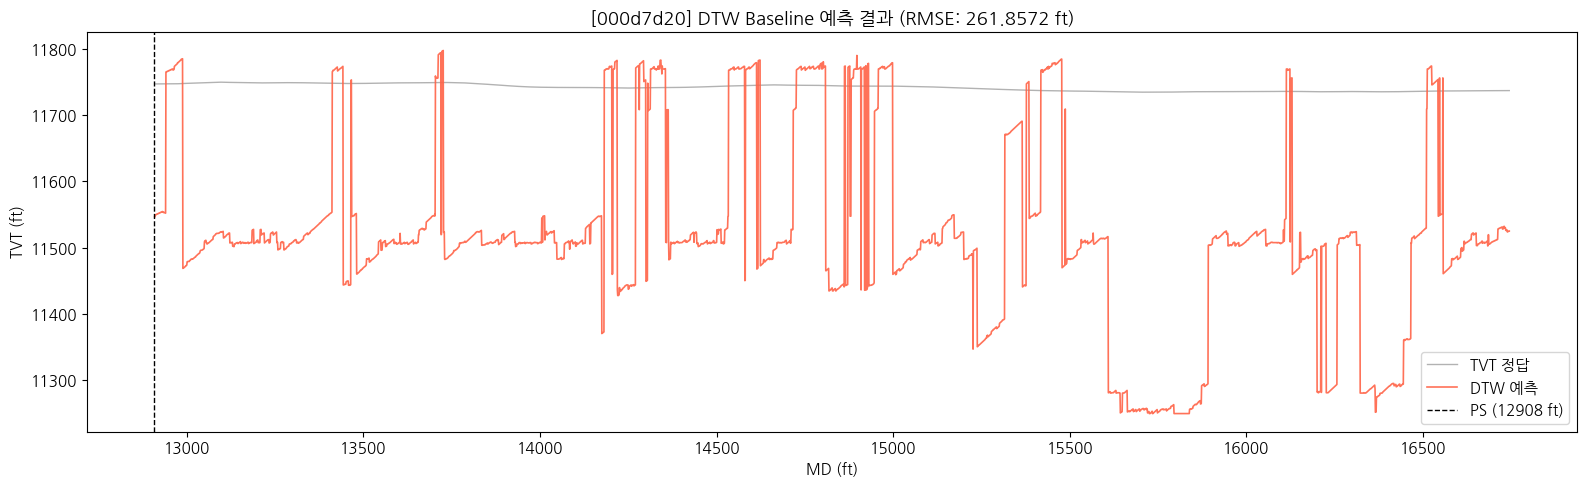

In [18]:
# ── DTW Baseline ─────────────────────────────────────────
from numpy.lib.stride_tricks import sliding_window_view
from sklearn.metrics import mean_squared_error
import numpy as np

# 데이터 준비
hw_before = hw[hw['MD'] <= ps_md].copy().reset_index(drop=True)
hw_after  = hw[hw['MD'] >  ps_md].copy().reset_index(drop=True)

tw_gr  = tw['GR'].values
tw_tvt = tw['TVT'].values

# ── 핵심 함수: GR 윈도우 매칭으로 TVT 예측 ──────────────
# 아이디어: 현재 지점 주변 GR 패턴을 Typewell GR 전체에서 슬라이딩하며
#           MSE가 가장 낮은 위치를 찾아 그 TVT를 예측값으로 사용

def predict_by_gr_matching(hw_gr, tw_gr, tw_tvt, window=100):
    n_tw   = len(tw_gr)
    n_pred = len(hw_gr)
    predictions = np.zeros(n_pred)

    for i in range(n_pred):
        # 현재 지점 주변 GR 윈도우 추출
        half  = window // 2
        s     = max(0, i - half)
        e     = min(n_pred, i + half)
        query = hw_gr[s:e]
        q_len = len(query)

        if q_len < 2 or q_len > n_tw:
            predictions[i] = tw_tvt[n_tw // 2]
            continue

        # Typewell 전체를 같은 길이의 윈도우로 쪼개서 MSE 비교
        tw_windows = sliding_window_view(tw_gr, q_len)          # 벡터화 슬라이딩
        mses       = np.mean((tw_windows - query) ** 2, axis=1) # 각 위치 MSE
        best_j     = np.argmin(mses)                            # 가장 유사한 위치

        # 해당 위치의 TVT를 예측값으로
        center = min(best_j + q_len // 2, n_tw - 1)
        predictions[i] = tw_tvt[center]

    return predictions

# ── 검증: PS 이전 구간으로 모델 성능 확인 ────────────────
print('검증 중 (PS 이전)...')
val_gr  = hw_before['GR'].values
val_tvt = hw_before['TVT'].values

val_pred = predict_by_gr_matching(val_gr, tw_gr, tw_tvt, window=100)
val_rmse = np.sqrt(mean_squared_error(val_tvt, val_pred))
print(f'[검증] RMSE: {val_rmse:.4f} ft')

# ── 예측: PS 이후 구간 ────────────────────────────────────
print('예측 중 (PS 이후)...')
pred_gr  = hw_after['GR'].values
pred_tvt = predict_by_gr_matching(pred_gr, tw_gr, tw_tvt, window=100)

hw_after['TVT_pred_dtw'] = pred_tvt

# PS 이후 실제 정답이 있으니까 RMSE 계산 가능
test_rmse = np.sqrt(mean_squared_error(hw_after['TVT'].values, pred_tvt))
print(f'[테스트] RMSE: {test_rmse:.4f} ft')

# ── 시각화 ───────────────────────────────────────────────
fig, ax = plt.subplots()

ax.plot(hw_after['MD'], hw_after['TVT'],          color='gray',    linewidth=1,   alpha=0.6, label='TVT 정답')
ax.plot(hw_after['MD'], hw_after['TVT_pred_dtw'], color='tomato',  linewidth=1.2, alpha=0.9, label='DTW 예측')
ax.axvline(ps_md, color='black', linestyle='--', linewidth=1, label=f'PS ({ps_md:.0f} ft)')

ax.set_xlabel('MD (ft)')
ax.set_ylabel('TVT (ft)')
ax.set_title(f'[{WELL_NAME}] DTW Baseline 예측 결과 (RMSE: {test_rmse:.4f} ft)')
ax.legend()
plt.tight_layout()
plt.show()

PS 직전 TVT    : 11747.37 ft
Typewell 앵커  : index 1047, TVT 11747.45 ft
DTW v2 RMSE (raw)    : 46.9564 ft
DTW v2 RMSE (smooth) : 45.5885 ft

DTW v2 RMSE : 46.9564 ft


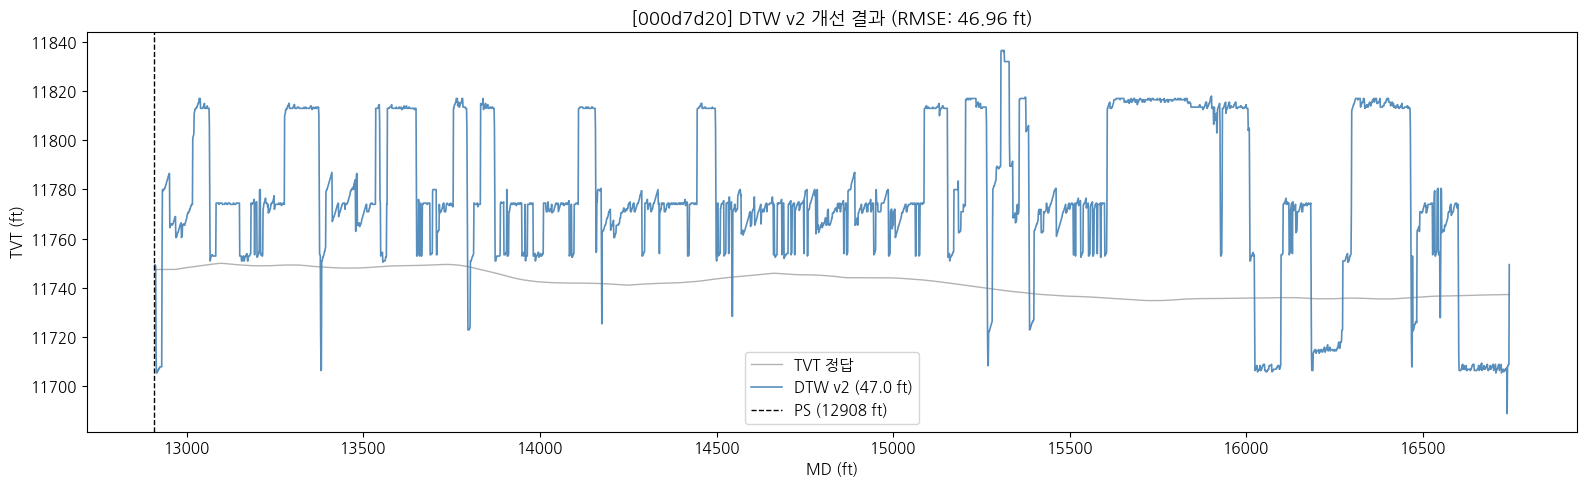

In [22]:
# ── DTW 개선 v2: 앵커 + 연속성 제약 ────────────────────
from sklearn.metrics import mean_squared_error
import numpy as np

tw_gr  = tw['GR'].values
tw_tvt = tw['TVT'].values
n_tw   = len(tw_gr)

hw_before = hw[hw['MD'] <= ps_md].copy().reset_index(drop=True)
hw_after  = hw[hw['MD'] >  ps_md].copy().reset_index(drop=True)

# ── Step 1: 앵커 설정 ─────────────────────────────────────
last_tvt   = hw_before['TVT_input'].dropna().iloc[-1]
anchor_idx = int((np.abs(tw_tvt - last_tvt)).argmin())

print(f'PS 직전 TVT    : {last_tvt:.2f} ft')
print(f'Typewell 앵커  : index {anchor_idx}, TVT {tw_tvt[anchor_idx]:.2f} ft')

# ── Step 2: 연속성 제약을 가진 순차 매칭 ─────────────────
GR_WINDOW    = 30
SEARCH_RANGE = 80

hw_after_gr    = hw_after['GR'].values
n_pred         = len(hw_after_gr)
predictions    = []
current_tw_idx = anchor_idx

for i in range(n_pred):
    half  = GR_WINDOW // 2
    s     = max(0, i - half)
    e     = min(n_pred, i + half)
    query = hw_after_gr[s:e]
    q_len = len(query)

    tw_s = max(0, current_tw_idx - SEARCH_RANGE)
    tw_e = min(n_tw - q_len, current_tw_idx + SEARCH_RANGE)

    best_mse = np.inf
    best_idx = current_tw_idx

    for j in range(tw_s, tw_e):
        segment = tw_gr[j : j + q_len]
        if len(segment) == q_len:
            mse = np.mean((query - segment) ** 2)
            if mse < best_mse:
                best_mse = mse
                best_idx = j + q_len // 2

    current_tw_idx = best_idx
    predictions.append(tw_tvt[min(best_idx, n_tw - 1)])

hw_after['TVT_pred_dtw_v2'] = predictions

# 후처리: 이동평균으로 튀는 값 완화
hw_after['TVT_pred_dtw_v2_smooth'] = (
    hw_after['TVT_pred_dtw_v2']
    .rolling(window=20, center=True, min_periods=1)
    .mean()
)

rmse_raw    = np.sqrt(mean_squared_error(hw_after['TVT'], hw_after['TVT_pred_dtw_v2']))
rmse_smooth = np.sqrt(mean_squared_error(hw_after['TVT'], hw_after['TVT_pred_dtw_v2_smooth']))

print(f'DTW v2 RMSE (raw)    : {rmse_raw:.4f} ft')
print(f'DTW v2 RMSE (smooth) : {rmse_smooth:.4f} ft')

# ── Step 3: 평가 ──────────────────────────────────────────
rmse_v2 = np.sqrt(mean_squared_error(hw_after['TVT'], hw_after['TVT_pred_dtw_v2']))
print(f'\nDTW v2 RMSE : {rmse_v2:.4f} ft')

# ── Step 4: 시각화 ────────────────────────────────────────
fig, ax = plt.subplots()

ax.plot(hw_after['MD'], hw_after['TVT'],             color='gray',      linewidth=1,   alpha=0.6, label='TVT 정답')
ax.plot(hw_after['MD'], hw_after['TVT_pred_dtw_v2'], color='steelblue', linewidth=1.2, alpha=0.9, label=f'DTW v2 ({rmse_v2:.1f} ft)')
ax.axvline(ps_md, color='black', linestyle='--', linewidth=1, label=f'PS ({ps_md:.0f} ft)')

ax.set_xlabel('MD (ft)')
ax.set_ylabel('TVT (ft)')
ax.set_title(f'[{WELL_NAME}] DTW v2 개선 결과 (RMSE: {rmse_v2:.2f} ft)')
ax.legend()
plt.tight_layout()
plt.show()

In [23]:
last_tvt = hw_before['TVT_input'].dropna().iloc[-1]
rmse_const = np.sqrt(mean_squared_error(hw_after['TVT'], np.full(len(hw_after), last_tvt)))
print(f'Constant baseline RMSE: {rmse_const:.4f} ft')

Constant baseline RMSE: 7.4544 ft
